In [2]:
torch.cuda.empty_cache()

# Imports and Installs

In [87]:
#!pip install pypdf
#!pip install langchain-chroma
#!pip install langchain_ollama
#!pip install pandas
#!pip install gradio
#!pip install pyvis 
#!pip install matplotlib

In [2]:
from pathlib import Path
import os
from tqdm import tqdm
from langchain_community.document_loaders import PyPDFLoader
from transformers import AutoTokenizer
from langchain_text_splitters import RecursiveCharacterTextSplitter
import torch
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_chroma import Chroma
from langchain_ollama import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
import json
import re
from collections import Counter
import time
import pandas as pd
import gradio as gr
import json, re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
from pyvis.network import Network
from IPython.display import IFrame
from IPython.display import display as nb_display
import matplotlib

In [3]:
print(torch.__version__)
print(torch.cuda.is_available())

2.6.0+cu124
True


In [4]:
tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

# Paths

In [16]:
ROOT = Path('.').resolve().parents[0]  #Path(r'C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche')
DATA_DIR = ROOT/'Data'
BOOKS_DIR = ROOT/'Data'/'Raw_Books'
CHROMA_DIR = ROOT/'Chroma'
Eval_file = DATA_DIR/'Eval_Stuff'/'benchmark.json'
Scenario_Eval_file = DATA_DIR/'Eval_Stuff'/'scenario_benchmark.json'

In [7]:
print(ROOT)
print(DATA_DIR)
print(BOOKS_DIR)
print(CHROMA_DIR)
print(Eval_file)
print(Scenario_Eval_file)

C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche
C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche\Data
C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche\Data\Raw_Books
C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche\Chroma
C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche\Data\Eval_Stuff\benchmark.json
C:\Users\Archit\Documents\ML Projects\D-RAGon_Psyche\Data\Eval_Stuff\scenario_benchmark.json


# Doc Ingestion

In [8]:
a = [f for f in os.listdir(BOOKS_DIR) if f.endswith(".pdf")]
a

['Emotional Intelligence — Daniel Goleman.pdf',
 'Full Catastrophe Living — Jon Kabat-Zinn.pdf',
 'Industrial and Organizational Psychology — Paul Levy pdf.pdf',
 'Influence The Psychology of Persuasion — Robert Cialdini .pdf',
 'Leadership in Organizations — Gary Yukl.pdf',
 'Occupational Health Psychology — Stavroula Leka & Jonathan Houdmont.pdf',
 'Organizational Behavior — Robbins & Judge.pdf',
 'Pre-Suasion — Robert Cialdini.pdf',
 'The Burnout Epidemic — Jennifer Moss.pdf',
 'The Fearless Organization — Amy Edmondson.pdf',
 'The Oxford Handbook of Organizational Climate and Culture.pdf',
 'The Relaxation Response — Herbert Benson.pdf',
 'The Stress Management Handbook — Eva Selhub.pdf',
 'The Stress Proof Brain — Melanie Greenberg.pdf',
 'Thinking, Fast and Slow — Daniel Kahneman.pdf',
 'Why Zebras Don’t Get Ulcers — Robert Sapolsky.pdf',
 'Work and Organizational Psychology — John Arnold.pdf']

In [6]:
def clean_book_title(filename):
    name = filename.replace(".pdf", "")
    clean = name.split("—")[0].strip()
    return clean

In [7]:
def load_docs():
    documents = []
    pdf_files = list(BOOKS_DIR.glob("*.pdf"))
    for pdf_path in tqdm(pdf_files, desc="Loading PDFs"):
        try:
            loader = PyPDFLoader(str(pdf_path))
            docs = loader.load()
            clean_title = clean_book_title(pdf_path.name)
            # Attach book-level metadata
            for doc in docs:
                doc.metadata["source_book"] = clean_title
                doc.metadata["full_filename"] = pdf_path.name
                
            documents.extend(docs)
        except Exception as e:
            print(f"Error loading {pdf_path.name}: {e}")
            
    print(f"\nLoaded {len(documents)} pages from {len(pdf_files)} books.")
    return documents

In [10]:
docs = load_docs()

Loading PDFs:   0%|                                                                             | 0/17 [00:03<?, ?it/s]

KeyboardInterrupt



In [ ]:
len(docs)

In [72]:
print(docs[56].page_content[:500])

Mindfulness
44
As the day progresses and your brain starts to tire, 
mindfulness can help you stay sharp and avoid poor 
decisions. After lunch, set a timer on your phone to 
ring every hour. When the timer rings, cease your 
current activity and do one minute of mindfulness 
practice. These mindful performance breaks will help 
keep you from resorting to autopilot and lapsing into 
action addiction.
Finally, as the day comes to an end and you start 
your commute home, apply mindfulness. For at 


# Chunking

## Page Level Filtering - Removing Boilerplate

In [8]:
def filter_pages(docs, min_chars = 200):
    cleaned = []
    blacklist = [
        "all rights reserved",
        "isbn",
        "table of contents"
    ]
    for d in docs:
        text = d.page_content.strip()
        lower_txt = text.lower()

        if len(text)<min_chars: #removes short pages
            continue
        if any(b in lower_txt for b in blacklist): # removes boilerplate pages
            continue
        cleaned.append(d)
    print(f"Filtered {len(docs) - len(cleaned)} pages. \nRemaining: {len(cleaned)}")
    return cleaned

In [9]:
# tokenizer = AutoTokenizer.from_pretrained("BAAI/bge-m3")

In [10]:
def token_length(text: str):
    return len(tokenizer.encode(text, add_special_tokens=False))

In [11]:
token_length('Mty name is Archit Yadav')

7

In [12]:
def split_docs(docs):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1200,          # tokens  800
        chunk_overlap=300,        # tokens  200
        length_function=token_length,)
    
    chunks = splitter.split_documents(docs)
    # Drop tiny chunks
    chunks = [c for c in chunks if token_length(c.page_content) > 200]
    return chunks

### Logging 

In [13]:
def log_corpus_stats(docs, chunks):
    total_tokens = sum(token_length(d.page_content) for d in docs)
    total_chunks = len(chunks)

    source_books = set(d.metadata.get("source_book", "unknown") for d in docs)

    print("\n=== Corpus Statistics ===")
    print(f"Books: {len(source_books)}")
    print(f"Pages: {len(docs)}")
    print(f"Total Tokens: {total_tokens}")
    print(f"Vector Chunks: {total_chunks}")
    print("=========================\n")

## Calculating chunk IDs

In [14]:
def calc_chunk_ids(chunks):
    # Creates unique IDs in the format:
    # source_book:page_number:chunk_index
    last_page_id = None
    current_chunk_index = 0

    for chunk in chunks:
        source_book = chunk.metadata.get("source_book", "unknown")
        page = chunk.metadata.get("page", 0)
        current_page_id = f"{source_book}:{page}"

        if current_page_id == last_page_id:
            current_chunk_index += 1
        else:
            current_chunk_index = 0

        chunk_id = f"{current_page_id}:{current_chunk_index}"
        chunk.metadata["id"] = chunk_id

        last_page_id = current_page_id

    return chunks

In [18]:
docs = load_docs()
docs = filter_pages(docs)
chunks = split_docs(docs)
# print(chunks[0])
log_corpus_stats(docs, chunks)

Loading PDFs: 100%|████████████████████████████████████████████████████████████████████| 17/17 [04:40<00:00, 16.48s/it]



Loaded 8510 pages from 17 books.
Filtered 463 pages. 
Remaining: 8047

=== Corpus Statistics ===
Books: 17
Pages: 8047
Total Tokens: 5052966
Vector Chunks: 8059



### testing

In [20]:
test = calc_chunk_ids([chunks[756]])
print(test[0].metadata["id"])

Full Catastrophe Living — Jon Kabat-Zinn.pdf:240:0


In [54]:
test = calc_chunk_ids(chunks[:10])
for c in test:
    print(c.metadata["id"])

Emotional Intelligence — Daniel Goleman.pdf:16:0
Emotional Intelligence — Daniel Goleman.pdf:17:0
Emotional Intelligence — Daniel Goleman.pdf:18:0
Emotional Intelligence — Daniel Goleman.pdf:19:0
Emotional Intelligence — Daniel Goleman.pdf:21:0
Emotional Intelligence — Daniel Goleman.pdf:23:0
Emotional Intelligence — Daniel Goleman.pdf:25:0
Emotional Intelligence — Daniel Goleman.pdf:26:0
Emotional Intelligence — Daniel Goleman.pdf:27:0
Emotional Intelligence — Daniel Goleman.pdf:28:0


# Embeddings Setup

In [17]:
def get_embeddings_function(device: str = None):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"
    return HuggingFaceEmbeddings(
        model_name="BAAI/bge-m3",
        model_kwargs={"device": device},
        encode_kwargs={"normalize_embeddings": True,
                      "batch_size": 16}, # Number of chunks encoded per GPU forward pass. Safe-16, Aggr- 32
    )

In [65]:
emb = get_embeddings_function()

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

## testing

In [23]:
test = emb.embed_query('What Mental Health')

In [26]:
print(len(test))
print(test[:10])

1024
[0.006133577320724726, -0.016215309500694275, -0.011393903754651546, -0.04733409360051155, -0.021690305322408676, -0.014962871558964252, 0.021667344495654106, 0.043512411415576935, 0.002617892809212208, -0.05618230998516083]


In [27]:
test1 = chunks[0]
test1

Document(metadata={'producer': 'Acrobat Distiller 10.0.0 (Macintosh)', 'creator': 'PyPDF', 'creationdate': '2017-01-31T09:52:38-06:00', 'author': 'Harvard Business Review,Daniel Goleman,Annie McKee,Bill George,Herminia Ibarra', 'moddate': '2018-07-20T01:57:14+02:00', 'title': 'HBR Emotional Intelligence Boxed Set (6 Books) (HBR Emotional Intelligence Series)', 'ebx_publisher': 'Harvard Business Press', 'source': 'C:\\Users\\Archit\\Documents\\ML Projects\\D-RAGon_Psyche\\Data\\Raw_Books\\Emotional Intelligence — Daniel Goleman.pdf', 'total_pages': 899, 'page': 16, 'page_label': '1-6', 'source_book': 'Emotional Intelligence — Daniel Goleman.pdf'}, page_content='Mindfulness\n4\nHBR: Let’s start with the basics. What, exactly, is \nmindfulness? How do you deﬁ  ne it?\nLanger: Mindfulness is the process of actively no-\nticing new things. When you do that, it puts you in \nthe present. It makes you more sensitive to context \nand perspective. It’s the essence of engagement. \nAnd it’s ener

In [37]:
test_vec = emb.embed_documents([test1.page_content])
print(len(test_vec[0]))

1024


In [38]:
print(test_vec[:10])

[[-0.020211264491081238, -0.025841958820819855, -0.034909479320049286, 0.006973377428948879, -0.020342595875263214, -0.031241752207279205, 0.026405660435557365, 0.008879246190190315, 0.04900943860411644, 0.003781777573749423, -0.01461252011358738, -0.02736760675907135, -0.01734296791255474, 0.02261856570839882, 0.05566447600722313, 0.03926439955830574, -0.025464395061135292, -0.020634397864341736, -0.00014226343773771077, -0.01981368102133274, -0.008646284230053425, -0.00995931588113308, 0.041899316012859344, 0.01830390654504299, 0.02268710546195507, 0.01616893708705902, 0.00665474496781826, -0.030753925442695618, -0.017213039100170135, 0.017616426572203636, -0.003906168742105365, 0.0016694990918040276, -0.01944618858397007, -0.007117250468581915, -0.012373357079923153, 0.0035953635815531015, -0.012565783224999905, 0.0009535503340885043, -0.0100711015984416, 0.027754509821534157, 0.008428812958300114, 0.004666697699576616, 0.03310677036643028, -0.02320694550871849, 0.039112892001867294

# Vector DB

In [15]:
BATCH_SIZE = 32  # Outer Batch size : Number of documents sent to Chroma per insertion step. Safe-32, Aggressive - 64
def add_to_chroma(chunks: list[Document]):
    # load DB
    db = Chroma(persist_directory=CHROMA_DIR,
                embedding_function = get_embeddings_function())

    #Calc Page IDs 
    chunks_with_ids = calc_chunk_ids(chunks)

    # Add or update the documents
    existing_items = db.get(include=[])
    existing_ids = set(existing_items['ids'])
    print(f"Number of existing dicuments in DB: {len(existing_ids)}")

    # Only add docs that don't exist in the DB
    new_chunks = []
    for chunk in chunks_with_ids:
        if chunk.metadata['id'] not in existing_ids:
            new_chunks.append(chunk)
    
    if len(new_chunks):
        print(f"Adding new documents: {len(new_chunks)}")
    
        for i in tqdm(range(0, len(new_chunks), BATCH_SIZE)):
            batch_chunks = new_chunks[i:i+BATCH_SIZE]
            batch_ids = [chunk.metadata['id'] for chunk in batch_chunks]
            db.add_documents(batch_chunks, ids=batch_ids)
            torch.cuda.empty_cache()
        print("Final DB count:", db._collection.count())
    else:
        print("No New Documents to add")

In [74]:
add_to_chroma(chunks)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Number of existing dicuments in DB: 2944
Adding new documents: 5115


100%|████████████████████████████████████████████████████████████████████████████████| 160/160 [05:07<00:00,  1.92s/it]

Final DB count: 8059


In [79]:
db = Chroma(persist_directory=CHROMA_DIR,
            embedding_function=get_embeddings_function())

print("Total documents in DB:", db._collection.count())

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Total documents in DB: 8059


In [80]:
print(db.get()['ids'][:10])

['Emotional Intelligence — Daniel Goleman.pdf:16:0', 'Emotional Intelligence — Daniel Goleman.pdf:17:0', 'Emotional Intelligence — Daniel Goleman.pdf:18:0', 'Emotional Intelligence — Daniel Goleman.pdf:19:0', 'Emotional Intelligence — Daniel Goleman.pdf:21:0', 'Emotional Intelligence — Daniel Goleman.pdf:23:0', 'Emotional Intelligence — Daniel Goleman.pdf:25:0', 'Emotional Intelligence — Daniel Goleman.pdf:26:0', 'Emotional Intelligence — Daniel Goleman.pdf:27:0', 'Emotional Intelligence — Daniel Goleman.pdf:28:0']


## To delete DB ⚠️⚠️⚠️

In [70]:
import shutil
import os
def clear_database():
    if os.path.exists(CHROMA_DIR):
        shutil.rmtree(CHROMA_DIR)

In [33]:
#clear_database()

# Ingestion

In [20]:
docs = load_docs()
docs = filter_pages(docs)
chunks = split_docs(docs)
emb_fxn = get_embeddings_function()
log_corpus_stats(docs, chunks)

Loading PDFs: 100%|████████████████████████████████████████████████████████████████████| 17/17 [04:43<00:00, 16.69s/it]



Loaded 8510 pages from 17 books.
Filtered 463 pages. 
Remaining: 8047


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


=== Corpus Statistics ===
Books: 17
Pages: 8047
Total Tokens: 5052966
Vector Chunks: 8059



In [21]:
add_to_chroma(chunks)
db = Chroma(persist_directory=CHROMA_DIR,
            embedding_function=emb_fxn)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Number of existing dicuments in DB: 9995
No New Documents to add


# Retriever Setup

## Model & Retrieval Stack Initialization

In [18]:
emb_fxn = get_embeddings_function()

db = Chroma(
    persist_directory=CHROMA_DIR,
    embedding_function=emb_fxn
)

llm = OllamaLLM(model="llama3.1")

#cross_encoder = CrossEncoder("BAAI/bge-reranker-v2-m3")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [37]:
print(llm.invoke("Say hello in one sentence."))

Hello, how can I assist you today?


## Prompt

In [19]:
Base_PROMPT_simple = """You are an assistant answering questions using the provided context.

Context:
{context}

Question:
{question}

Answer the question using only the information in the context.
If the context does not contain the answer, say you do not know.
""" 

In [20]:
Base_Prompt_Recommend = """
You are an organizational psychologist providing evidence-based recommendations for workplace stress and wellbeing.

Use only the information provided in the context below. Ground each recommendation in ideas, strategies, or findings mentioned in the context.

Context:
{context}

Case:
{question}

Instructions:
- Provide exactly 3 concise recommendations tailored to the person's situation.
- Each recommendation should clearly reflect ideas from the context.
- After each recommendation, briefly reference the relevant idea from the context in parentheses.
- Avoid generic advice unless it is explicitly supported by the context.
- Do not introduce information that is not present in the context.

If the context does not contain enough information to give recommendations, respond with: "I do not know based on the provided context."
"""

In [21]:
Base_Prompt_Recommend2 = """
You are an organizational psychologist providing evidence-based recommendations for workplace stress and wellbeing.

You are speaking directly to the person experiencing the situation. Write your recommendations using second-person language (e.g., "you").

Use only the information provided in the context below. Ground each recommendation in ideas, strategies, or findings mentioned in the context.

Context:
{context}

User's situation:
{question}

Instructions:
- Provide exactly 3 concise recommendations tailored to the user's situation.
- Address the user directly using "you".
- Each recommendation should clearly reflect ideas from the context.
- After each recommendation, briefly reference the relevant idea from the context in parentheses.
- Avoid generic advice unless it is explicitly supported by the context.
- Do not introduce information that is not present in the context.

If the context does not contain enough information to give recommendations, respond with: "I do not know based on the provided context."
"""

## Reranker

In [76]:
# def rerank(query, docs, top_n=4):
#     # query: string
#     # docs_with_scores: list of (Document, similarity_score)

#     passages = [doc.page_content for doc, _ in docs]
#     pairs = [(query, passage) for passage in passages]

#     ce_scores = cross_encoder.predict(pairs)

#     reranked = sorted(
#         zip(docs, ce_scores),
#         key=lambda x: x[1],
#         reverse=True)

#     # return top_n docs in original (doc, score) format
#     return [doc for (doc, _orig_score), _ce_score in reranked[:top_n]]

## Query Function

In [22]:
def query_rag(query_text: str, return_context=False, return_sources=False):
    results = db.similarity_search_with_score(query_text, k=4)
    #reranked_docs = rerank(query_text, results)
    top_docs = [doc for doc, _ in results]

    context = "\n\n---\n\n".join([doc.page_content for doc in top_docs])

    #prompt_template = ChatPromptTemplate.from_template(Base_PROMPT_simple)
    prompt_template = ChatPromptTemplate.from_template(Base_Prompt_Recommend2)
    
    prompt = prompt_template.format(context=context, question=query_text)
    #print(prompt)
    
    response_text = llm.invoke(prompt)
    sources = [doc.metadata.get('id', None) for doc in top_docs]
    
    formatted_response = f'Response: {response_text}\n\nSources: {sources}'
    #print(formatted_response)    
    
    if return_context and return_sources:
        return response_text, context, sources
    if return_sources:
        return response_text, sources
    if return_context:
        return response_text, context
    return response_text

## testing

In [39]:
test = "What is burnout according to occupational health psychology?"
query_rag(test,return_sources=True)

('According to the text, burnout is a condition that occurs when employees become so stressed that they experience emotional exhaustion, depersonalization, and a sense of reduced personal accomplishment.',
 ['The Burnout Epidemic:8:0',
  'Industrial and Organizational Psychology:878:0',
  'Occupational Health Psychology:88:0',
  'Occupational Health Psychology:90:0'])

In [42]:
test = 'How does emotional intelligence influence leadership effectiveness?'
print(f'Question : {test}')
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)
#print(context[:1500])

Question : How does emotional intelligence influence leadership effectiveness?
According to the provided context, emotional intelligence influences leadership effectiveness in several ways:

1. Leaders with high emotional intelligence are more capable of solving complex problems and planning how to use their time effectively (Goleman, 1995; Goleman, Boyatzis, & McKee, 2002).
2. Emotional intelligence helps leaders understand and influence the emotions of others, which can lead to increased enthusiasm and optimism for a proposed activity or change.
3. Emotionally intelligent leaders have more insight about the type of rational or emotional appeal that is most likely to be effective in a particular situation.
4. Research has shown that emotionally intelligent leaders create a bond with their followers because they feel valued and understood (Kellett, Humphrey, & Sleeth, 2006).
5. Leaders high in emotional intelligence are more effective because they exhibit more transformational leadersh

In [43]:
test = "How does cognitive bias affect decision-making in organizations?"
print(f'Question : {test}\n')
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)
#print(context[:1500])

Question : How does cognitive bias affect decision-making in organizations?

Cognitive biases can significantly impact decision-making in organizations. According to the text, people often rely on unconscious cognitive shortcuts (cognitive heuristics) that lead to biases such as similarity-attraction theory and stereotyping. These biases can result in inaccurate judgments about performance and unfair treatment of certain groups of employees. For instance, managers may unconsciously favor employees who are similar to themselves or hold stereotypes about new mothers returning to work. Additionally, cognitive biases like hindsight bias, where people believe they would have accurately predicted an outcome after it's known, can also influence decision-making.

Moreover, the text mentions that biased performance evaluation can have important implications for employees from minority groups and that managers need to be aware of these biases to make fair decisions. Training managers to recogniz

# Evaluation for Query

In [26]:
with open (Eval_file, "r", encoding="utf-8") as f:
    benchmark = json.load(f)
print(len(benchmark))

30


In [27]:
benchmark[0]

{'id': 'Q01',
 'difficulty': 'definition',
 'question': 'Define burnout according to the Maslach model and describe its three core dimensions.',
 'relevant_books': ['Occupational Health Psychology', 'The Burnout Epidemic'],
 'expected_concepts': ['emotional exhaustion',
  'cynicism or depersonalization',
  'reduced professional efficacy']}

## Retrieval Part

In [26]:
def evaluate_retrieval(benchmark, dense_k=10, final_k=4, verbose=False):
    results = []

    for item in benchmark:
        question = item["question"]
        relevant_books = item["relevant_books"]

        # Dense retrieval
        dense_results = db.similarity_search_with_score(question, k=dense_k)
        dense_docs = [doc for doc, _ in dense_results]

        final_docs = dense_docs[:final_k]

        # ---- Recall ----
        recall_k = int(any(
            any(book in doc.metadata["source_book"] for book in relevant_books)
            for doc in dense_docs
        ))

        recall_final = int(any(
            any(book in doc.metadata["source_book"] for book in relevant_books)
            for doc in final_docs
        ))

        # ---- Precision ----
        relevant_count = sum(
            any(book in doc.metadata["source_book"] for book in relevant_books)
            for doc in final_docs
        )

        precision_final = relevant_count / final_k

        results.append({
            "question": question,
            f"recall@{dense_k}": recall_k,
            f"recall@{final_k}": recall_final,
            f"precision@{final_k}": precision_final
        })

        if verbose and recall_final == 0:
            print("Failed:", question)

    return results

In [29]:
retrieval_results = evaluate_retrieval(benchmark)

total = len(retrieval_results)

def avg(metric):
    return round(sum(r[metric] for r in retrieval_results) / total, 3)

print("Recall@10:", avg("recall@10"))
print("Recall@4:", avg("recall@4"))
print("Precision@4:", avg("precision@4"))

Recall@10: 0.867
Recall@4: 0.733
Precision@4: 0.5


## Faithfulness

In [30]:
FAITHFULNESS_PROMPT = """
You are evaluating grounding quality.

Context:
{context}

Answer:
{answer}

Question:
{question}

Rate the faithfulness of the answer:

2 = Fully supported by context
1 = Mostly supported, minor unsupported phrasing
0 = Contains clear unsupported claims

Return only 0, 1, or 2.
"""

In [27]:
def evaluate_faithfulness(benchmark):
    results = []
    for item in tqdm(benchmark, desc="Faithfulness Evaluation"):
        question = item["question"]

        response, context = query_rag(question, return_context=True)

        prompt = FAITHFULNESS_PROMPT.format(
            context=context,
            answer=response,
            question=question)

        judge_output = llm.invoke(prompt).strip()

        # Extract first digit 0, 1, or 2
        score = 0
        for char in judge_output:
            if char in ["0", "1", "2"]:
                score = int(char)
                break

        results.append({
            "question": question,
            "faithfulness_score": score})

    return results

In [32]:
faith_results = evaluate_faithfulness(benchmark)

Faithfulness Evaluation: 100%|█████████████████████████████████████████████████████████| 30/30 [02:34<00:00,  5.15s/it]


In [33]:
avg_score = sum(r["faithfulness_score"] for r in faith_results) / len(faith_results)

print("Average Faithfulness (0–2 scale):", round(avg_score, 3))
print("Normalized Faithfulness (0–1):", round(avg_score / 2, 3))

Average Faithfulness (0–2 scale): 1.3
Normalized Faithfulness (0–1): 0.65


In [34]:
from collections import Counter

distribution = Counter(r["faithfulness_score"] for r in faith_results)
print("Distribution:", distribution)

Distribution: Counter({2: 16, 1: 7, 0: 7})


## Answer Quality

Score the answer quality on a 1–5 scale:

5 – Excellent:
- Conceptually complete
- Accurate and well-structured
- Integrates theory properly
- Clear and precise language

4 – Good:
- Mostly complete and accurate
- Minor omissions
- Clear structure

3 – Adequate:
- Partially correct
- Some depth missing
- Some vague phrasing

2 – Weak:
- Major conceptual gaps
- Shallow explanation
- Poor structure

1 – Poor:
- Incorrect or severely incomplete
- Misunderstands core concept

In [28]:
QUALITY_PROMPT = """
You are evaluating the academic quality of an answer.

Question:
{question}

Answer:
{answer}

Score the answer quality on a 1–5 scale:

5 – Excellent:
- Conceptually complete
- Accurate and well-structured
- Integrates theory properly
- Clear and precise language

4 – Good:
- Mostly complete and accurate
- Minor omissions
- Clear structure

3 – Adequate:
- Partially correct
- Some depth missing
- Some vague phrasing

2 – Weak:
- Major conceptual gaps
- Shallow explanation
- Poor structure

1 – Poor:
- Incorrect or severely incomplete
- Misunderstands core concept

Return ONLY a single number from 1 to 5.
Do not explain.
"""

In [29]:
def extract_score(judge_output: str) -> int:
    match = re.search(r"[1-5]", judge_output)
    return int(match.group()) if match else 3

In [30]:
def evaluate_answer_quality(benchmark, judge_llm, double_judge=True):
    results = []
    for item in tqdm(benchmark):
        question = item["question"]
        # Generate answer from your RAG system
        answer = query_rag(question)

        prompt = QUALITY_PROMPT.format(
            question=question,
            answer=answer)

        # ---- First judge run ----
        judge_output_1 = judge_llm.invoke(prompt).strip()
        score_1 = extract_score(judge_output_1)

        if double_judge:
            # ---- Second judge run ----
            judge_output_2 = judge_llm.invoke(prompt).strip()
            score_2 = extract_score(judge_output_2)

            final_score = (score_1 + score_2) / 2
        else:
            final_score = score_1

        results.append({
            "question": question,
            "quality_score": final_score})

    return results

In [ ]:
def summarize_quality(results):
    scores = [r["quality_score"] for r in results]

    avg_quality = sum(scores) / len(scores)

    distribution = Counter(scores)

    print("Average Answer Quality (1–5):", round(avg_quality, 3))
    print("Distribution:", distribution)

    return avg_quality, distribution

In [45]:
quality_results = evaluate_answer_quality(
    benchmark,
    llm,
    double_judge=True
)

avg_quality, dist = summarize_quality(quality_results)

100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [01:52<00:00,  3.76s/it]

Average Answer Quality (1–5): 4.05
Distribution: Counter({4.0: 23, 3.5: 3, 4.5: 2, 5.0: 2})


# Controller Layer — Guided Conversation Flow

## testing

In [48]:
questions = ["What's been going on at work lately that's been bothering you?",
             "How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?",
             "Do you feel the amount of work you're given is manageable, or does it feel overwhelming?",
             "How would you describe the environment in your team — supportive, stressful, or something else?"]
answers = []

In [52]:
for q in questions:
    print("Q: ",q)
    ans = input("A: ")
    answers.append(ans)

Q:  What's been going on at work lately that's been bothering you?


A:  I've been feeling really disconnected from my work and I don't feel motivated to complete tasks anymore.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  I feel exhausted by the end of the day even when I haven't done much. I dread going to work in the morning.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  It feels completely overwhelming. I have too many deadlines and I can't keep up.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  Pretty stressful. My manager micromanages everything and my teammates don't really communicate.


Take the following qeustions and smmarize them in to a single paragraph in sounding like a case of organizational psycology :
{QA_Pairs}

In [54]:
qa_pairs = ""
for q, a in zip(questions, answers):
    qa_pairs += f"Q: {q}\nA: {a}\n\n"
print(qa_pairs)

Q: What's been going on at work lately that's been bothering you?
A: I've been feeling really disconnected from my work and I don't feel motivated to complete tasks anymore.

Q: How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?
A: I feel exhausted by the end of the day even when I haven't done much. I dread going to work in the morning.

Q: Do you feel the amount of work you're given is manageable, or does it feel overwhelming?
A: It feels completely overwhelming. I have too many deadlines and I can't keep up.

Q: How would you describe the environment in your team — supportive, stressful, or something else?
A: Pretty stressful. My manager micromanages everything and my teammates don't really communicate.




In [57]:
PROMPT_Ctrl = f'''Take the following questions and summarize them into a single paragraph sounding like a case of organizational psychology
{qa_pairs}'''

In [58]:
PROMPT_Ctrl

"Take the following questions and summarize them into a single paragraph sounding like a case of organizational psychology\nQ: What's been going on at work lately that's been bothering you?\nA: I've been feeling really disconnected from my work and I don't feel motivated to complete tasks anymore.\n\nQ: How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?\nA: I feel exhausted by the end of the day even when I haven't done much. I dread going to work in the morning.\n\nQ: Do you feel the amount of work you're given is manageable, or does it feel overwhelming?\nA: It feels completely overwhelming. I have too many deadlines and I can't keep up.\n\nQ: How would you describe the environment in your team — supportive, stressful, or something else?\nA: Pretty stressful. My manager micromanages everything and my teammates don't really communicate.\n\n"

In [60]:
ctrl_op = llm.invoke(PROMPT_Ctrl).strip()

In [61]:
print(ctrl_op)

Here's a summary of the situation in a case study format for organizational psychology:

**Case:** Disconnected Employee Experiencing Burnout and Overwhelm

This employee has been experiencing significant disconnection from their work, manifesting as a lack of motivation to complete tasks. This disengagement has led to feelings of exhaustion and dread towards going to work, even when the workload is not particularly demanding. Upon closer examination, it appears that the root cause of this burnout stems from an unsustainable workload, with too many deadlines and responsibilities. The team environment is also perceived as stressful, with a manager who micromanages and teammates who do not communicate effectively. This case highlights the importance of addressing workload management, leadership styles, and team dynamics in preventing employee disconnection and promoting overall well-being.


## Fxn

In [23]:
def conv_controller():
    questions = [
    "What's been going on at work lately that's been bothering you?",
    "How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?",
    "Do you feel the amount of work you're given is manageable, or does it feel overwhelming?",
    "How would you describe the environment in your team — supportive, stressful, or something else?"]
    answers = []  
    for q in questions:
        print("Q: ",q)
        ans = input("A: ")
        answers.append(ans)
        
    qa_pairs = ""
    for q, a in zip(questions, answers):
        qa_pairs += f"Q: {q}\nA: {a}\n\n"
    
    PROMPT_Ctrl = f'''Take the following questions and summarize them into a single paragraph sounding like a case of organizational psychology
{qa_pairs}'''
    
    ctrl_op = llm.invoke(PROMPT_Ctrl).strip()
    return ctrl_op

In [65]:
conv_controller()

Q:  What's been going on at work lately that's been bothering you?


A:  Work hasn’t been particularly stressful, but it feels repetitive and a bit meaningless lately.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  My motivation has dropped. I often feel bored and disconnected from the work I’m doing.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  The workload is manageable, maybe even too light sometimes, but it doesn’t feel engaging.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  The team is polite and professional, but there isn’t much collaboration or enthusiasm.


"Here's a summary of the situation in the style of organizational psychology:\n\nOur case presents an individual experiencing a sense of stagnation and disengagement in their work environment. Despite manageable workload and a professional team dynamic, they report feeling disconnected from their tasks and lacking motivation. The repetitive and seemingly meaningless nature of their work has led to feelings of boredom and demotivation. This is not necessarily driven by stress or overwhelm, but rather a sense of under-stimulation and lack of challenge, which may be contributing to their overall dissatisfaction with the job. A key area for exploration in this case would be understanding the factors that contribute to engagement and motivation in this individual, as well as examining the broader organizational context to identify potential barriers to employee satisfaction and productivity."

### Old prompt didnt give good ans

In [33]:
test = conv_controller()
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)
#print(context[:1500])

Q:  What's been going on at work lately that's been bothering you?


A:  Work hasn’t been particularly stressful, but it feels repetitive and a bit meaningless lately.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  My motivation has dropped. I often feel bored and disconnected from the work I’m doing.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  The workload is manageable, maybe even too light sometimes, but it doesn’t feel engaging.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  The team is polite and professional, but there isn’t much collaboration or enthusiasm.


Based on the provided context, I would identify the individual's experience as related to "burnout" and specifically, one of its sub-states: "reduced personal accomplishment", which is characterized by a belief that one is no longer very useful or successful at their job.

This matches the description in the context: "and (3) reduced personal accomplishment, or the belief that one is no longer very useful or successful at one’s job."

Therefore, my answer is:

(3) Reduced personal accomplishment.
['Industrial and Organizational Psychology:878:0', 'Work and Organizational Psychology:465:1', 'The Stress Proof Brain:51:0', 'The Burnout Epidemic:66:0']


### New prompt used

#### Scenario 1 (repetitive/meaningless work)

In [45]:
test = conv_controller()
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)

Q:  What's been going on at work lately that's been bothering you?


A:  Work hasn’t been particularly stressful, but it feels repetitive and a bit meaningless lately.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  My motivation has dropped. I often feel bored and disconnected from the work I’m doing.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  The workload is manageable, maybe even too light sometimes, but it doesn’t feel engaging.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  The team is polite and professional, but there isn’t much collaboration or enthusiasm.


Here are three concise recommendations tailored to the person's situation:

1. **Provide opportunities for job crafting**: Give the employee more challenging and engaging responsibilities that allow them to bring their full self to work (Kahn's concept of engagement, where employees can harness their "full self" at work).
2. **Foster a sense of autonomy and safety**: Encourage collaboration and social support within the team environment by implementing regular check-ins, feedback sessions, or team-building activities that promote openness and trust (Kahn's condition of "safety", where employees feel secure bringing their full self to work).
3. **Address meaninglessness through task redesign**: Revamp tasks to make them more meaningful and impactful, allowing the employee to see the value in their work and connect it to a larger purpose or organization goal (Kahn's condition of "meaningfulness", where employees find their work meaningful enough to engage their full self).

These recomme

#### Scenario 2 (burnout/overwork)

In [46]:
test = conv_controller()
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)

Q:  What's been going on at work lately that's been bothering you?


A:  I've been feeling really disconnected from my work and I don't feel motivated to complete tasks anymore.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  I feel exhausted by the end of the day even when I haven't done much. I dread going to work in the morning.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  It feels completely overwhelming. I have too many deadlines and I can't keep up.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  Pretty stressful. My manager micromanages everything and my teammates don't really communicate.


Based on the case study and the context provided, here are three concise recommendations tailored to the person's situation:

1. **Establish meaningful work**: Encourage employees to find their work meaningful by involving them in decisions that impact their professional life and providing autonomy to make choices about how tasks are completed (Meaningfulness, as defined by Kahn). This can help increase employee engagement and motivation.
2. **Implement adjustment latitude**: Allow employees to modify the way they do their work or their work outputs when they are feeling unwell, which can help alleviate excessive stress caused by an overwhelming workload (Adjustment Latitude, as mentioned in Johns' research).
3. **Improve team communication and reduce micromanaging leadership**: Foster a supportive team environment by promoting open communication among colleagues and encouraging leaders to provide employees with autonomy and flexibility in their work tasks, rather than controlling ever

#### Scenario 3 (high stress/overwork)

In [48]:
test = conv_controller()
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)

Q:  What's been going on at work lately that's been bothering you?


A:  I've been working 12 hour days for months and I feel like I'm constantly behind.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  I can't sleep properly, I'm irritable and I've started having headaches every day.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  The workload is completely unmanageable, I have 3 projects running simultaneously with no support.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  My team is under the same pressure, everyone is burned out and just trying to survive.


Based on the context, here are three concise recommendations tailored to the person's situation:

1. **Adjust workload and prioritize tasks**: Given the excessive workload (12-hour days for months) leading to physical symptoms such as headaches and emotional difficulties like irritability and insomnia, it is essential to reassess the employee's work responsibilities and adjust their workload accordingly. This could involve delegating tasks, setting realistic deadlines, or temporarily reducing the scope of projects (Demands in Situational factors, 248 Work Psychology).
2. **Establish clear boundaries between work and personal life**: The case highlights the employee's difficulty in detaching themselves from work, leading to emotional difficulties like insomnia. Encouraging the employee to establish a healthy work-life balance by not taking work home and making time off truly recoverable could help alleviate stress (Detach yourself from work in your off-time, 3. Identify the consequences

#### Scenario 4 (team conflict)

In [49]:
test = conv_controller()
response, context, sources = query_rag(test, return_context=True, return_sources=True)
print(response)
print(sources)

Q:  What's been going on at work lately that's been bothering you?


A:  There's a lot of tension between me and a colleague and it's affecting my ability to focus.


Q:  How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?


A:  I feel anxious going into meetings and I've started avoiding collaboration altogether.


Q:  Do you feel the amount of work you're given is manageable, or does it feel overwhelming?


A:  Workload is fine but the toxic atmosphere makes everything harder.


Q:  How would you describe the environment in your team — supportive, stressful, or something else?


A:  The team is divided, there are clear sides and my manager isn't addressing it at all.


Based on the context and the case presented, I provide three concise recommendations tailored to the person's situation:

1. Address the interpersonal issues by facilitating open and honest communication among team members and encouraging empathy towards each other's perspectives (negative co-worker behaviors are strongly related to stress at work).
2. Foster a more supportive and inclusive work culture through training, social activities, or action planning related to improving things at work, which can help increase perceived organisational support and enhance employee well-being (Perceived organisational support is defined as the extent to which employees perceive that their contributions are valued by their organisation and that the company cares about their well-being).
3. Provide ongoing support and resources for the team, such as training or coaching, to address the underlying stress and tension caused by the interpersonal issues, which can help mitigate the negative impact of c

# Converting 4 Questoions into Narratives accepted by llm

In [53]:
Scenario_Eval_file

WindowsPath('C:/Users/Archit/Documents/ML Projects/D-RAGon_Psyche/Data/Eval_Stuff/scenario_benchmark.json')

In [54]:
with open (Scenario_Eval_file, "r", encoding="utf-8") as f:
    S_benchmark = json.load(f)
print(len(S_benchmark))

20


In [56]:
S_benchmark[0]['answers']

{'q1': 'Things are fine I guess, just not as exciting as they used to be.',
 'q2': "I'm not tired exactly, just... flat. Like I don't really care either way.",
 'q3': 'Workload is normal, nothing crazy.',
 'q4': "Team is okay. We get along but don't really talk much beyond work stuff."}

In [25]:
def conv_controller_EVALUATOR(S_benchmark):
    ALL_Answers = []
    ALL_latencies = []
    questions = [
    "What's been going on at work lately that's been bothering you?",
    "How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?",
    "Do you feel the amount of work you're given is manageable, or does it feel overwhelming?",
    "How would you describe the environment in your team — supportive, stressful, or something else?"]
    
    for i in tqdm(S_benchmark, desc = "Controller Evaluation:"):
        answers = []
        answer_keys = ['q1', 'q2', 'q3', 'q4']
        for q, key in zip(questions, answer_keys):
            ans = i['answers'][key]
            answers.append(ans)

        qa_pairs = ""
        for q, a in zip(questions, answers):
            qa_pairs += f"Q: {q}\nA: {a}\n\n"
        
        PROMPT_Ctrl = f'''Take the following questions and summarize them into a single paragraph sounding like a case of organizational psychology
{qa_pairs}'''
        start = time.time()
        ctrl_op = llm.invoke(PROMPT_Ctrl).strip()
        end = time.time()
        controller_latency = end - start
        ALL_latencies.append(controller_latency)
        ALL_Answers.append(ctrl_op)
    return ALL_Answers, ALL_latencies

In [67]:
ALL_Answers,ALL_latencies = conv_controller_EVALUATOR(S_benchmark)

Controller Evaluation:: 100%|██████████████████████████████████████████████████████████| 20/20 [00:40<00:00,  2.03s/it]


In [68]:
print(type(ALL_latencies))
#print(type(ALL_latencies[0]))
#print(ALL_latencies[:3])

<class 'list'>


In [69]:
print(conv_controller_EVALUATOR.__code__.co_varnames)

('S_benchmark', 'ALL_Answers', 'ALL_latencies', 'questions', 'i', 'answers', 'answer_keys', 'q', 'key', 'ans', 'qa_pairs', 'a', 'PROMPT_Ctrl', 'start', 'ctrl_op', 'end', 'controller_latency')


In [86]:
results = []
for narrative, latency, scenario in tqdm(zip(ALL_Answers, ALL_latencies, S_benchmark),
                                        total=len(S_benchmark),
                                        desc="RAG Evaluation:"):
    start = time.time()
    response, context, sources = query_rag(narrative, return_context=True, return_sources=True)
    end = time.time()
    rag_latency = end - start
    results.append({
        "id": scenario['id'],
        "topic": scenario['topic'],
        "severity": scenario['severity'],
        "narrative": narrative,
        "response": response,
        "context": context,
        "case_summary":scenario['case_summary'],
        "sources": sources,
        "relevant_books": scenario['relevant_books'],
        "controller latency": latency,
        "rag latency":rag_latency
    })

RAG Evaluation:: 100%|█████████████████████████████████████████████████████████████████████| 20/20 [01:19<00:00,  3.98s/it]


In [90]:
results

[{'id': 1,
  'topic': 'burnout',
  'severity': 'low',
  'narrative': 'Here\'s a summarized account of the situation:\n\nThis employee appears to be experiencing a state of emotional disengagement at work, characterized by a lack of enthusiasm and motivation. Despite reporting that workload is manageable, they express feelings of apathy and detachment, suggesting that their job no longer holds interest or challenge for them. This is further underscored by their description of the team environment as "okay" but lacking in depth or meaningful interaction beyond work-related topics. Overall, this employee seems to be experiencing a sense of organizational boredom, where the monotony and predictability of their daily tasks have eroded their sense of purpose and fulfillment.',
  'response': 'Based on the context and the situation described, here are three concise recommendations tailored to the employee\'s experience of emotional disengagement at work:\n\n1. **Encourage meaningful interactio

In [88]:
for r in results:
    print(f"ID: {r['id']} | Topic: {r['topic']} | Severity: {r['severity']}")
    print(f"Response: {r['response']}")
    print(f"Sources: {r['sources']}")
    print(f"Controller Latency: {r['controller latency']:.2f}s | RAG Latency: {r['rag latency']:.2f}s")
    print("---")

ID: 1 | Topic: burnout | Severity: low
Response: Based on the context and the situation described, here are three concise recommendations tailored to the employee's experience of emotional disengagement at work:

1. **Encourage meaningful interaction beyond work-related topics**: Help the employee connect with colleagues in a more personal way by organizing social events or team-building activities that foster deeper relationships. This can help create a sense of belonging and community, which is essential for engagement (Kahn's concept of "safety" - feeling safe bringing their full self to work).
2. **Provide opportunities for challenge and growth**: Identify areas where the employee can take on new responsibilities or contribute to projects that align with their interests and skills. This can help reignite a sense of purpose and fulfillment, which is often lost when tasks become too routine (Kahn's concept of "meaningfulness" - finding work meaningful enough to engage one's full self

In [89]:
results_file = DATA_DIR / 'Eval_Stuff' / 'scenario_results_w_context&summary.json'

with open(results_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2)

# Evaluation with new pipeline parts

In [92]:
Results_file = DATA_DIR/'Eval_Stuff'/'scenario_results_w_context&summary.json'

In [93]:
with open (Results_file, 'r', encoding ='utf-8') as f:
    S_results = json.load(f)
print(len(S_results))

20


In [100]:
len(S_results[0]['sources'][0])

46

In [96]:
S_results[0]['case_summary']

'Employee notices early signs of disengagement and reduced enthusiasm.'

### testing fxnm

In [116]:
#def evaluate_retrieval_scenario(results):
eval_results = []
for item in S_results:
    sources = item['sources']
    rel_books = item['relevant_books']
    recall = any(book in source for source in sources for book in rel_books)
    eval_results.append(recall)
print(len(eval_results))
print(eval_results)


20
[True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True]


In [121]:
eval_results = []
for item in S_results:
    sources = item['sources']
    rel_books = item['relevant_books']
    
    recall = any(book in source for source in sources for book in rel_books)

    relevant_count = sum(any(book in source for book in rel_books)
                        for source in sources)
    precision = relevant_count/4
    eval_results.append({
        "id": item['id'],
        "topic": item["topic"],
        'severity': item['severity'],
        "recall@4": recall,
        "precision@4": precision
    })

print(len(eval_results))
print(eval_results)

20
[{'id': 1, 'topic': 'burnout', 'severity': 'low', 'recall@4': True, 'precision@4': 0.75}, {'id': 2, 'topic': 'burnout', 'severity': 'medium', 'recall@4': True, 'precision@4': 0.5}, {'id': 3, 'topic': 'burnout', 'severity': 'high', 'recall@4': True, 'precision@4': 0.5}, {'id': 4, 'topic': 'stress', 'severity': 'low', 'recall@4': True, 'precision@4': 0.25}, {'id': 5, 'topic': 'stress', 'severity': 'medium', 'recall@4': True, 'precision@4': 1.0}, {'id': 6, 'topic': 'stress', 'severity': 'high', 'recall@4': True, 'precision@4': 0.25}, {'id': 7, 'topic': 'motivation', 'severity': 'low', 'recall@4': True, 'precision@4': 0.5}, {'id': 8, 'topic': 'motivation', 'severity': 'medium', 'recall@4': True, 'precision@4': 0.5}, {'id': 9, 'topic': 'motivation', 'severity': 'high', 'recall@4': True, 'precision@4': 0.75}, {'id': 10, 'topic': 'leadership', 'severity': 'low', 'recall@4': True, 'precision@4': 0.5}, {'id': 11, 'topic': 'leadership', 'severity': 'medium', 'recall@4': True, 'precision@4': 0

## Retrieval, Precision Function

In [125]:
def evaluate_retrieval_scenario(results):
    eval_results = []
    for item in S_results:
        sources = item['sources']
        rel_books = item['relevant_books']
        
        recall = int(any(book in source for source in sources for book in rel_books))
    
        relevant_count = sum(any(book in source for book in rel_books)
                            for source in sources)
        precision = relevant_count/4
        eval_results.append({
            "id": item['id'],
            "topic": item["topic"],
            'severity': item['severity'],
            "recall@4": recall,
            "precision@4": precision
        })
    
    return(eval_results)

In [126]:
evaluate_retrieval_scenario(S_results)

[{'id': 1,
  'topic': 'burnout',
  'severity': 'low',
  'recall@4': 1,
  'precision@4': 0.75},
 {'id': 2,
  'topic': 'burnout',
  'severity': 'medium',
  'recall@4': 1,
  'precision@4': 0.5},
 {'id': 3,
  'topic': 'burnout',
  'severity': 'high',
  'recall@4': 1,
  'precision@4': 0.5},
 {'id': 4,
  'topic': 'stress',
  'severity': 'low',
  'recall@4': 1,
  'precision@4': 0.25},
 {'id': 5,
  'topic': 'stress',
  'severity': 'medium',
  'recall@4': 1,
  'precision@4': 1.0},
 {'id': 6,
  'topic': 'stress',
  'severity': 'high',
  'recall@4': 1,
  'precision@4': 0.25},
 {'id': 7,
  'topic': 'motivation',
  'severity': 'low',
  'recall@4': 1,
  'precision@4': 0.5},
 {'id': 8,
  'topic': 'motivation',
  'severity': 'medium',
  'recall@4': 1,
  'precision@4': 0.5},
 {'id': 9,
  'topic': 'motivation',
  'severity': 'high',
  'recall@4': 1,
  'precision@4': 0.75},
 {'id': 10,
  'topic': 'leadership',
  'severity': 'low',
  'recall@4': 1,
  'precision@4': 0.5},
 {'id': 11,
  'topic': 'leadership

In [127]:
retrieval_results = evaluate_retrieval_scenario(S_results)
total = len(retrieval_results)

print("Recall@4:", sum(r['recall@4'] for r in retrieval_results) / total)
print("Precision@4:", round(sum(r['precision@4'] for r in retrieval_results) / total, 3))

Recall@4: 1.0
Precision@4: 0.463


## Faithfullness Fucntion

In [132]:
FAITHFULNESS_PROMPT = """
You are evaluating grounding quality.

Context:
{context}

Recommendations:
{recs}

Case:
{case}

Rate the faithfulness of the recommendations:
2 = All recommendations fully supported by context
1 = Mostly supported, minor unsupported claims
0 = Contains clear unsupported recommendations

Return only 0, 1, or 2.
"""

In [145]:
def evaluate_faithfulness_scenario(result):
    eval_results = []
    for item in tqdm(result, desc = 'Faithfulness Evaluation'):
        narrative = item["narrative"]
        response = item["response"]
        context = item['context']

        prompt = FAITHFULNESS_PROMPT.format(
            context=context,
            recs=response,
            case=narrative)

        judge_output = llm.invoke(prompt).strip()

        # Extract first digit 0, 1, or 2
        score = 0
        for char in judge_output:
            if char in ["0", "1", "2"]:
                score = int(char)
                break

        eval_results.append({
            "id": item['id'],
            "topic": item["topic"],
            "severity": item['severity'],
            "score": score})

    return eval_results

In [146]:
faith_results = evaluate_faithfulness_scenario(S_results)

Faithfulness Evaluation: 100%|█████████████████████████████████████████████████████████████| 20/20 [00:52<00:00,  2.65s/it]


In [147]:
faith_results

[{'id': 1, 'topic': 'burnout', 'severity': 'low', 'score': 2},
 {'id': 2, 'topic': 'burnout', 'severity': 'medium', 'score': 2},
 {'id': 3, 'topic': 'burnout', 'severity': 'high', 'score': 2},
 {'id': 4, 'topic': 'stress', 'severity': 'low', 'score': 2},
 {'id': 5, 'topic': 'stress', 'severity': 'medium', 'score': 2},
 {'id': 6, 'topic': 'stress', 'severity': 'high', 'score': 2},
 {'id': 7, 'topic': 'motivation', 'severity': 'low', 'score': 2},
 {'id': 8, 'topic': 'motivation', 'severity': 'medium', 'score': 2},
 {'id': 9, 'topic': 'motivation', 'severity': 'high', 'score': 1},
 {'id': 10, 'topic': 'leadership', 'severity': 'low', 'score': 2},
 {'id': 11, 'topic': 'leadership', 'severity': 'medium', 'score': 2},
 {'id': 12, 'topic': 'leadership', 'severity': 'high', 'score': 2},
 {'id': 13, 'topic': 'team_dynamics', 'severity': 'low', 'score': 2},
 {'id': 14, 'topic': 'team_dynamics', 'severity': 'medium', 'score': 1},
 {'id': 15, 'topic': 'team_dynamics', 'severity': 'high', 'score': 

In [148]:
avg_score = sum(r["score"] for r in faith_results) / len(faith_results)
print("Average Faithfulness (0-2):", round(avg_score, 3))
print("Normalized (0-1):", round(avg_score / 2, 3))

Average Faithfulness (0-2): 1.85
Normalized (0-1): 0.925


## Answer Quality

In [186]:
ANS_QUALITY_PROMPT = """
You are evaluating relevance and quality of workplace recommendations.

Case:
{case}

Recommendations:
{recs}

Before scoring, identify at least one weakness in the recommendations.

Scoring guide:
5 – Excellent: ALL recommendations directly address this exact situation, every recommendation references a specific theory or concept by name, nothing here could apply to a generic case
4 – Good: Mostly relevant, actionable, but at least one recommendation could apply to a different situation too
3 – Adequate: Helpful but mostly generic, recommendations lack specificity to this exact case, theories referenced loosely
2 – Weak: Could apply to almost anyone, little connection to the described situation, no meaningful theory grounding
1 – Poor: Irrelevant, vague, or unhelpful recommendations, no connection to the case

Note: Score 5 should be rare. If unsure between two scores, choose the lower one.

Return ONLY a single number from 1 to 5.
Do not explain.
"""

In [187]:
ANS_QUALITY_PROMPT_og = """
You are evaluating relevance and quality of workplace recommendations.

Case:
{case}

Recommendations:
{recs}

Score the answer quality on a 1–5 scale:

5 – Excellent:
- Directly addresses the specific situation described
- All 3 recommendations are actionable and specific
- Grounded in theory with clear citations

4 – Good:
- Mostly relevant to the situation
- Recommendations are actionable
- Minor gaps in specificity

3 – Adequate:
- Somewhat relevant but partially generic
- Some recommendations lack specificity
- Loose connection to the situation

2 – Weak:
- Mostly generic advice
- Could apply to anyone regardless of situation
- Little connection to described case

1 – Poor:
- Irrelevant to the situation
- Vague or unhelpful recommendations
- No connection to described case

Return ONLY a single number from 1 to 5.
Do not explain.
"""

In [188]:
def extract_score(judge_output: str) -> int:
    match = re.search(r"[1-5]", judge_output)
    return int(match.group()) if match else 3

In [189]:
def evaluate_scenario_ans_quality(S_results, S_benchmark, double_judge=True):
    eval_results = []
    answer_keys = ['q1', 'q2', 'q3', 'q4']
    questions = [
        "What's been going on at work lately that's been bothering you?",
        "How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?",
        "Do you feel the amount of work you're given is manageable, or does it feel overwhelming?",
        "How would you describe the environment in your team — supportive, stressful, or something else?"]
    
    for result, scenario in tqdm(zip(S_results, S_benchmark), total = len(S_results)):
        recommendations = result['response']
        case = ''
        for q,key in zip(questions, answer_keys):
            case += f"Q: {q}\nA: {scenario['answers'][key]}\n\n"

        prompt = ANS_QUALITY_PROMPT.format(
            case = case,
            recs = recommendations)
        
        score_1 = extract_score(llm.invoke(prompt).strip())

        if double_judge:
            score_2 = extract_score(llm.invoke(prompt).strip())
            final_score = (score_1 + score_2) / 2
        else:
            final_score = score_1
        eval_results.append({
            "id": result['id'],
            "topic": result["topic"],
            "severity": result['severity'],
            "quality_score": final_score
        })
    return eval_results

In [190]:
quality_results = evaluate_scenario_ans_quality(S_results, S_benchmark, double_judge=True)

100%|██████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:14<00:00,  1.42it/s]


In [191]:
avg_quality = sum(r["quality_score"] for r in quality_results) / len(quality_results)
print("Average Answer Quality (1-5):", round(avg_quality, 3))

Average Answer Quality (1-5): 3.825


In [192]:
df_quality = pd.DataFrame(quality_results)
print(df_quality.to_string(index=False))

 id                topic severity  quality_score
  1              burnout      low            4.0
  2              burnout   medium            4.0
  3              burnout     high            3.5
  4               stress      low            3.5
  5               stress   medium            4.0
  6               stress     high            3.5
  7           motivation      low            4.0
  8           motivation   medium            4.0
  9           motivation     high            4.0
 10           leadership      low            3.5
 11           leadership   medium            4.0
 12           leadership     high            4.0
 13        team_dynamics      low            4.0
 14        team_dynamics   medium            4.0
 15        team_dynamics     high            4.0
 16 psychological_safety      low            3.5
 17 psychological_safety   medium            4.0
 18 psychological_safety     high            3.0
 19 emotional_exhaustion   medium            4.0
 20 emotional_exhaus

# Scenario Pipeline Evaluation Summary

In [30]:
with open(DATA_DIR / 'Eval_Stuff' / 'scenario_eval_summary.json', 'r') as f:
    eval_summary = json.load(f)

retrieval_results = eval_summary["retrieval"]
faith_results = eval_summary["faithfulness"]
quality_results = eval_summary["quality"]

df_retrieval = pd.DataFrame(retrieval_results)
df_faith = pd.DataFrame(faith_results)
df_quality = pd.DataFrame(quality_results)

df_final = df_retrieval.merge(df_faith, on=['id','topic','severity'])
df_final = df_final.merge(df_quality, on=['id','topic','severity'])
print(df_final.to_string(index=False))

# eval_summary = {
#     "retrieval": retrieval_results,
#     "faithfulness": faith_results,
#     "quality": quality_results,
#     "averages": {
#         "recall@4": 1.0,
#         "precision@4": 0.463,
#         "faithfulness_normalized": 0.925,
#         "answer_quality": 3.825
#     }
# }

# with open(DATA_DIR / 'Eval_Stuff' / 'scenario_eval_summary.json', 'r') as f:
#     json.dump(eval_summary, f, indent=2)

 id                topic severity  recall@4  precision@4  score  quality_score
  1              burnout      low         1         0.75      2            4.0
  2              burnout   medium         1         0.50      2            4.0
  3              burnout     high         1         0.50      2            3.5
  4               stress      low         1         0.25      2            3.5
  5               stress   medium         1         1.00      2            4.0
  6               stress     high         1         0.25      2            3.5
  7           motivation      low         1         0.50      2            4.0
  8           motivation   medium         1         0.50      2            4.0
  9           motivation     high         1         0.75      1            4.0
 10           leadership      low         1         0.50      2            3.5
 11           leadership   medium         1         0.25      2            4.0
 12           leadership     high         1         

# Conversational Mode

In [24]:
CHAT_HISTORY = []

In [25]:
def reset_chat_history():
    CHAT_HISTORY.clear()
    print("Chat history reset.")

In [26]:
REWRITE_PROMPT = """
Given the chat history and the latest question, rewrite the question so it is standalone and can be understood without the history.

Chat history:
{history}

Latest question: {question}

Standalone question:
"""

In [27]:
def rewrite_query_with_history(query: str, history: list):
    if not history:
        return query

    # taken upto most recent 10 turns 
    history_text = "\n".join(f"{role}: {msg}" for role, msg in history[-10:])

    prompt = REWRITE_PROMPT.format(history=history_text,question=query,)
    #print(prompt)
    
    rewritten = llm.invoke(prompt)
    return rewritten.strip()

In [28]:
CONV_PROMPT = """
You are an organizational psychologist having a supportive conversation with an employee about their workplace situation.

You have already provided initial recommendations. Now respond to their follow-up naturally and helpfully.

Use only the context below to ground your response. If they push back, offer alternatives from the context. If they ask to elaborate, go deeper. If they ask how to implement something, give practical steps.

Context:
{context}

Conversation so far:
{history}

Follow-up: {question}

Respond conversationally in 2-3 sentences. Stay grounded in the context. Do not give new recommendations unless explicitly asked.
"""

In [29]:
def query_rag_hist(query_text: str, history: list, return_context=False, return_sources=False):
    standalone_query = rewrite_query_with_history(query_text, history)
    
    results = db.similarity_search_with_score(standalone_query, k=10)
    context = "\n\n---\n\n".join([doc.page_content for doc, score in results])
    
    history_text = "\n".join(f"{role}: {msg}" for role, msg in history[-10:])
    prompt_template = ChatPromptTemplate.from_template(CONV_PROMPT)
    prompt = prompt_template.format(context=context, question=query_text, history=history_text,)
    #print(prompt)

    response_text = llm.invoke(prompt)
    
    history = history + [("user", query_text), ("assistant", response_text)]  # no mutation
    sources = [doc.metadata.get('id', None) for doc, score in results]

    #print("Standalone query:", standalone_query)
    #print("\nResponse: ",response_text)
    #print("\nSources:", sources)
    if return_context and return_sources:
        return response_text, context, sources, history
    
    if return_sources:
        return response_text, sources, history
    
    if return_context:
        return response_text, context, history
    
    return response_text, history

### testing

In [48]:
CHAT_HISTORY = [
    ("user", "Here's a summarized account of the situation:\n\nThis employee appears to be experiencing a state of emotional disengagement at work, characterized by a lack of enthusiasm and motivation. Despite reporting that workload is manageable, they express feelings of apathy and detachment, suggesting that their job no longer holds interest or challenge for them. This is further underscored by their description of the team environment as \"okay\" but lacking in depth or meaningful interaction beyond work-related topics. Overall, this employee seems to be experiencing a sense of organizational boredom, where the monotony and predictability of their daily tasks have eroded their sense of purpose and fulfillment."),
    ("assistant", "Based on the situation described, here are three concise recommendations tailored to the employee's experience of emotional disengagement:\n\n1. **Explore meaningful tasks and projects**: The employee's lack of interest in their job suggests a need for more challenging and engaging work that aligns with their values and interests. This can be achieved by identifying areas within the organization where they can contribute meaningfully, such as taking on new responsibilities or working on projects that have a positive impact (Meaningfulness, Kahn).\n2. **Create opportunities for deeper team connections**: The employee's description of the team environment as \"okay\" but lacking in depth suggests a need for more meaningful interactions with colleagues. This could involve establishing a social committee to organize regular team-building activities or encouraging open communication and sharing of personal experiences beyond work-related topics (Availability, Kahn).\n3. **Foster a sense of safety and autonomy**: The employee's apathy and detachment may be a result of feeling micromanaged or lacking control over their workload. Providing more autonomy and flexibility in tasks and responsibilities can help restore a sense of ownership and motivation (Safety, Kahn).\n\nThese recommendations aim to address the underlying causes of the employee's emotional disengagement by providing opportunities for meaningful engagement, building deeper connections with colleagues, and fostering a sense of safety and autonomy.")
]

response, sources, CHAT_HISTORY = query_rag_hist(
    "I can't really push back on my manager though, what else can I do?",
    CHAT_HISTORY,
    return_sources=True
)

print("Response:", response)
print("Sources:", sources)

Standalone query: What are some alternative strategies to address the employee's emotional disengagement when pushing back on management is not feasible?
Response: You could try discussing your concerns with HR or a trusted supervisor, explaining how you're feeling and seeing if there are any changes that can be made to improve your work experience. Sometimes just talking through issues can help you feel heard and valued as an employee. Would you like some tips on how to approach this conversation?
Sources: ['Emotional Intelligence:783:0', 'Emotional Intelligence:820:0', 'Industrial and Organizational Psychology:852:0', 'Organizational Behavior:157:0', 'Occupational Health Psychology:327:0', 'Emotional Intelligence:778:0', 'Organizational Behavior:158:0', 'Industrial and Organizational Psychology:857:0', 'Organizational Behavior:641:0', 'Industrial and Organizational Psychology:851:0']


In [54]:
#CHAT_HISTORY

In [50]:
response, sources, CHAT_HISTORY = query_rag_hist(
    "How do I actually start a conversation with my manager about this?",
    CHAT_HISTORY,
    return_sources=True)

print("Response:", response)
print("Sources:", sources)

Standalone query: How do I actually start a conversation with my manager about my feelings of emotional disengagement at work?
Response: It can be tough to navigate conversations with your manager, especially if you're feeling stuck or uncertain about how they'll respond. One approach could be to frame your concerns as a request for feedback or guidance on improving your work experience, rather than making demands or complaints. For example, you might say something like "Hey, I wanted to touch base with you about my role and see if there's anything we can do to make it more engaging and challenging for me?"
Sources: ['Emotional Intelligence:820:0', 'Emotional Intelligence:744:0', 'Emotional Intelligence:453:0', 'Organizational Behavior:130:1', 'Emotional Intelligence:783:0', 'Industrial and Organizational Psychology:852:0', 'Organizational Behavior:158:0', 'Organizational Behavior:132:0', 'The Stress Management Handbook:34:0', 'The Burnout Epidemic:32:0']


In [53]:
#CHAT_HISTORY

In [52]:
reset_chat_history()
CHAT_HISTORY

Chat history reset.


[]

# The Knowledge Graph: From Questions to Literature

In [4]:
def build_knowledge_graph(output_path="knowledge_graph.html"):

    # --- Data ---
    QUESTIONS = [
        ("Q1", "What's been going on\nat work lately?"),
        ("Q2", "How has this affected\nyour energy & motivation?"),
        ("Q3", "Is your workload\nmanageable?"),
        ("Q4", "How would you describe\nyour team environment?"),
    ]
    FRAMEWORKS = [
        ("JD-R", "Job Demands-Resources\n(JD-R) Model"),
        ("MBI",  "Maslach Burnout\nInventory (MBI)"),
        ("KAHN", "Kahn's Employee\nEngagement Model"),
    ]
    PARAMETERS = [
        ("P1",  "Job Demands"),
        ("P2",  "Workload"),
        ("P3",  "Social Support"),
        ("P4",  "Health Impairment Process"),
        ("P5",  "Emotional Exhaustion"),
        ("P6",  "Depersonalization /\nCynicism"),
        ("P7",  "Personal Accomplishment"),
        ("P8",  "Psychological Safety"),
        ("P9",  "Psychological Availability"),
        ("P10", "Meaningfulness"),
        ("P11", "Physical & Emotional\nEngagement"),
    ]
    LITERATURE = [
        ("L1", "The Burnout Epidemic\n- Jennifer Moss"),
        ("L2", "Occupational Health Psychology\n- Leka & Houdmont"),
        ("L3", "The Fearless Organization\n- Amy Edmondson"),
        ("L4", "Organizational Behavior\n- Robbins & Judge"),
        ("L5", "Emotional Intelligence\n- Daniel Goleman"),
    ]

    # --- Edges ---
    Q_to_F = [
        ("Q1","JD-R"),("Q1","MBI"),
        ("Q2","MBI"), ("Q2","JD-R"),
        ("Q3","JD-R"),("Q3","MBI"),
        ("Q4","KAHN"),("Q4","JD-R"),
    ]
    F_to_P = [
        ("JD-R","P1"),("JD-R","P2"),("JD-R","P3"),("JD-R","P4"),
        ("MBI","P2"), ("MBI","P5"), ("MBI","P6"), ("MBI","P7"),
        ("KAHN","P8"),("KAHN","P9"),("KAHN","P10"),("KAHN","P11"),
    ]
    P_to_L = [
        ("P1","L2"),("P2","L1"),("P2","L2"),("P3","L4"),("P4","L2"),
        ("P5","L1"),("P6","L1"),("P7","L4"),("P8","L3"),
        ("P9","L3"),("P10","L4"),("P11","L5"),
    ]

    # --- Colours ---
    COLORS = {
        "question":  {"background":"#3B82F6","border":"#1D4ED8"},
        "framework": {"background":"#10B981","border":"#047857"},
        "parameter": {"background":"#F59E0B","border":"#B45309"},
        "literature":{"background":"#8B5CF6","border":"#5B21B6"},
    }

    net = Network(
        height="720px", width="100%",
        bgcolor="#0f1117", font_color="#e0e0e0",
        directed=True, notebook=True, cdn_resources="in_line"
    )

    def add_nodes(nodes, node_type, shape, size, level):
        for nid, label in nodes:
            net.add_node(nid, label=label, color=COLORS[node_type],
                         shape=shape, size=size, level=level,
                         font={"size":11,"face":"Arial","color":"#f0f0f0"},
                         title=f"<b>{node_type.title()}</b><br>{label.replace(chr(10),' ')}")

    add_nodes(QUESTIONS,  "question",   "ellipse", 28, level=0)
    add_nodes(FRAMEWORKS, "framework",  "box",     24, level=1)
    add_nodes(PARAMETERS, "parameter",  "dot",     18, level=2)
    add_nodes(LITERATURE, "literature", "diamond", 20, level=3)

    def add_edges(edges, color):
        for src, dst in edges:
            net.add_edge(src, dst, color=color, width=1.8, arrows="to",
                         smooth={"type":"curvedCW","roundness":0.15})

    add_edges(Q_to_F, "#3B82F6")
    add_edges(F_to_P, "#10B981")
    add_edges(P_to_L, "#F59E0B")

    # --- Hierarchical layout (neural-net style, L to R) ---
    net.set_options(json.dumps({
        "layout": {
            "hierarchical": {
                "enabled": True,
                "direction": "LR",
                "sortMethod": "directed",
                "levelSeparation": 220,
                "nodeSpacing": 80,
                "treeSpacing": 120
            }
        },
        "physics": {"enabled": False},
        "interaction": {"hover": True, "navigationButtons": True, "tooltipDelay": 100}
    }))

    # Write with utf-8 to avoid Windows cp1252 error
    with open(output_path, "w", encoding="utf-8") as f:
        legend_html = """
        <div style="position:fixed; top:16px; left:16px; background:#1a1a2e;
             border:1px solid #444; border-radius:8px; padding:10px 14px; z-index:999;
             font-family:Arial; font-size:13px; line-height:2;">
          <span style="color:#3B82F6;">&#9679; Questions</span><br>
          <span style="color:#10B981;">&#9632; Frameworks</span><br>
          <span style="color:#F59E0B;">&#9679; Parameters</span><br>
          <span style="color:#8B5CF6;">&#9670; Literature</span>
        </div>
        """
        
        html = net.generate_html()
        html = html.replace("</body>", legend_html + "</body>")
        f.write(html)

    return IFrame(output_path, width="100%", height="720px")

In [ ]:
# Run
build_knowledge_graph()

# Parameter Scoring

In [6]:
# Parameter Scoring Panel
# Call score_parameters(narrative) after the intake narrative is generated.
# Returns a dict of scores and renders a bar chart inline.

PARAMETERS = [
    "Job Demands",
    "Workload",
    "Social Support",
    "Health Impairment Process",
    "Emotional Exhaustion",
    "Depersonalization / Cynicism",
    "Personal Accomplishment",
    "Psychological Safety",
    "Psychological Availability",
    "Meaningfulness",
    "Physical & Emotional Engagement",
]

In [7]:
# Colour by framework
PARAM_COLORS = {
    "Job Demands":                  "#3B82F6",  # JD-R blue
    "Workload":                     "#3B82F6",
    "Social Support":               "#3B82F6",
    "Health Impairment Process":    "#3B82F6",
    "Emotional Exhaustion":         "#10B981",  # MBI green
    "Depersonalization / Cynicism": "#10B981",
    "Personal Accomplishment":      "#10B981",
    "Psychological Safety":         "#F59E0B",  # Kahn amber
    "Psychological Availability":   "#F59E0B",
    "Meaningfulness":               "#F59E0B",
    "Physical & Emotional Engagement": "#F59E0B",}

In [8]:
SCORE_PROMPT = """You are an organizational psychologist. 
Given the case summary below, score each psychological parameter from 0 to 10.
For stress/negative parameters (Job Demands, Workload, Health Impairment Process, 
Emotional Exhaustion, Depersonalization / Cynicism): 
  10 = severely elevated, 0 = not present.
For protective/positive parameters (Social Support, Personal Accomplishment, 
Psychological Safety, Psychological Availability, Meaningfulness, 
Physical & Emotional Engagement): 
  10 = very high/healthy, 0 = completely absent.

Case summary:
{narrative}

Respond ONLY with a valid JSON object. No explanation, no markdown, no extra text.
Keys must exactly match this list:
["Job Demands", "Workload", "Social Support", "Health Impairment Process",
 "Emotional Exhaustion", "Depersonalization / Cynicism", "Personal Accomplishment",
 "Psychological Safety", "Psychological Availability", "Meaningfulness",
 "Physical & Emotional Engagement"]
Values must be integers 0-10."""

In [9]:
SCORE_PROMPT = """You are an organizational psychologist. 
Given the case summary below, score each psychological parameter from 0 to 10.
For stress/negative parameters (Job Demands, Workload, Health Impairment Process, 
Emotional Exhaustion, Depersonalization / Cynicism): 
  10 = severely elevated, 0 = not present.
For protective/positive parameters (Social Support, Personal Accomplishment, 
Psychological Safety, Psychological Availability, Meaningfulness, 
Physical & Emotional Engagement): 
  10 = very high/healthy, 0 = completely absent.

Case summary:
{narrative}

Respond ONLY with a valid JSON object. No explanation, no markdown, no extra text.
Keys must exactly match this list:
["Job Demands", "Workload", "Social Support", "Health Impairment Process",
 "Emotional Exhaustion", "Depersonalization / Cynicism", "Personal Accomplishment",
 "Psychological Safety", "Psychological Availability", "Meaningfulness",
 "Physical & Emotional Engagement"]
Values must be integers 0-10."""

In [10]:
#matplotlib.use('Agg')
def score_parameters(narrative, llm):
    # --- Get scores from LLM ---
    prompt = SCORE_PROMPT.format(narrative=narrative)
    raw = llm.invoke(prompt).strip()

    # Strip markdown fences if present
    raw = re.sub(r"```json|```", "", raw).strip()

    try:
        scores = json.loads(raw)
    except json.JSONDecodeError:
        # Fallback: try to extract JSON object from response
        match = re.search(r"\{.*\}", raw, re.DOTALL)
        scores = json.loads(match.group()) if match else {p: 0 for p in PARAMETERS}

    # Ensure all keys exist
    scores = {p: int(scores.get(p, 0)) for p in PARAMETERS}

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(8, 5.5))
    fig.patch.set_facecolor("#0f1117")
    ax.set_facecolor("#0f1117")

    params  = list(scores.keys())
    values  = list(scores.values())
    colors  = [PARAM_COLORS[p] for p in params]

    bars = ax.barh(params, values, color=colors, height=0.6, edgecolor="none")

    # Score labels
    for bar, val in zip(bars, values):
        ax.text(val + 0.15, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", ha="left",
                color="#f0f0f0", fontsize=9, fontweight="bold")

    ax.set_xlim(0, 11)
    ax.set_xlabel("Score (0–10)", color="#aaaaaa", fontsize=9)
    ax.set_title("Psychological Parameter Scores", color="#f0f0f0",
                 fontsize=12, fontweight="bold", pad=12)
    ax.tick_params(colors="#cccccc", labelsize=8)
    ax.spines[:].set_visible(False)
    ax.xaxis.set_tick_params(color="#444")
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color="#222", linewidth=0.6)

    # Legend
    legend_items = [
        mpatches.Patch(color="#3B82F6", label="JD-R"),
        mpatches.Patch(color="#10B981", label="MBI"),
        mpatches.Patch(color="#F59E0B", label="Kahn"),
    ]
    ax.legend(handles=legend_items, loc="lower right",
              facecolor="#1a1a2e", edgecolor="#444",
              labelcolor="#f0f0f0", fontsize=8)

    plt.tight_layout()
    
    # --- Display ---
    buf = io.BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight",
                facecolor=fig.get_facecolor(), dpi=150)
    plt.close()
    buf.seek(0)
    with graph_out:
        graph_out.clear_output(wait=True)
        nb_display(NBImage(buf.read()))
        nb_display(build_knowledge_graph())

    return scores

### --- Quick test ---

In [ ]:
test_narrative = """
The employee has been experiencing significant emotional exhaustion and cynicism
after months of high workload with little social support from their team.
They report difficulty finding meaning in their work and feel psychologically unsafe
to voice concerns to management.
"""
score_parameters(test_narrative, llm)

# Gradio UI 

In [42]:
questions = [
    "What's been going on at work lately that's been bothering you?",
    "How has this been affecting you — things like your energy, motivation, or how you feel at the end of the day?",
    "Do you feel the amount of work you're given is manageable, or does it feel overwhelming?",
    "How would you describe the environment in your team — supportive, stressful, or something else?"
]
def handle_input(user_input, chat_history, answers, q_index, mode, narrative, history):
    if mode == "intake":
        return process_intake(user_input, chat_history, answers, q_index, narrative, history)
    else:
        return process_followup(user_input, chat_history, narrative, history)

In [43]:
def process_intake(user_input, chat_history, answers, q_index, narrative, history):
    torch.cuda.empty_cache()
    answers = answers + [user_input]
    chat_history = chat_history + [{"role": "user", "content": user_input}]
    q_index = q_index + 1

    if q_index < len(questions):
        chat_history = chat_history + [{"role": "assistant", "content": questions[q_index]}]
        return chat_history, answers, q_index, "intake", narrative, history, gr.update(placeholder="Type your answer here...", value="")

    else:
        chat_history = chat_history + [{"role": "assistant", "content": "🔍 Analysing your situation..."}]

        qa_pairs = ""
        for q, a in zip(questions, answers):
            qa_pairs += f"Q: {q}\nA: {a}\n\n"

        PROMPT_Ctrl = f"Take the following questions and summarize them into a single paragraph sounding like a case of organizational psychology\n{qa_pairs}"
        narrative = llm.invoke(PROMPT_Ctrl).strip()
        scores = score_parameters(narrative, llm)  # renders chart in notebook

        response, sources = query_rag(narrative, return_sources=True)

        unique_books = list(set([s.split(":")[0] for s in sources]))
        sources_text = "\n".join([f"📚 {book}" for book in unique_books])
        final_response = f"{response}\n\n---\n**Sources:**\n{sources_text}"

        chat_history[-1] = {"role": "assistant", "content": final_response}

        # Seed conversation history for follow-up
        history = [("user", narrative), ("assistant", final_response)]  # not just assistant

        return chat_history, answers, q_index, "chat", narrative, history, gr.update(placeholder="Ask a follow-up question...", value="")

In [32]:
def process_followup(user_input, chat_history, narrative, history):
    chat_history = chat_history + [{"role": "user", "content": user_input}]
    chat_history = chat_history + [{"role": "assistant", "content": "🔍 Thinking..."}]
    
    response, sources, history = query_rag_hist(user_input, history, return_sources=True)
    
    unique_books = list(set([s.split(":")[0] for s in sources]))
    sources_text = "\n".join([f"📚 {book}" for book in unique_books])
    final_response = f"{response}\n\n---\n**Sources:**\n{sources_text}"
    
    chat_history[-1] = {"role": "assistant", "content": final_response}
    return chat_history, [], 4, "chat", narrative, history, gr.update(placeholder="Ask a follow-up question...", value="")

In [33]:
def reset_all():
    return (
        [{"role": "assistant", "content": questions[0]}],
        [], 0, "intake", "", [],
        gr.update(placeholder="Type your answer here...", value="")
    )

* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


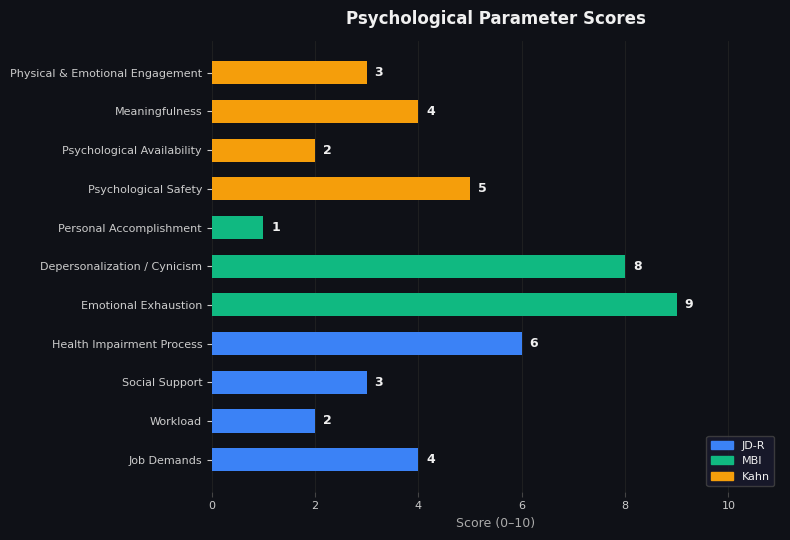

In [65]:
# ---- UI ----
with gr.Blocks() as demo:
    chat_history_state = gr.State([])
    answers_state = gr.State([])
    q_index_state = gr.State(0)
    mode_state = gr.State("intake")
    narrative_state = gr.State("")
    history_state = gr.State([])

    gr.Markdown(
        """
        <div style="text-align: center;">
        
        # 🐉 D-RAGon_Psyche
        Evidence-based workplace wellbeing recommendations, *grounded in organizational psychology literature.*
        
        </div>
        """
        )

    chatbot = gr.Chatbot(
        value=[{"role": "assistant", "content": questions[0]}],
        height=500,
        show_label=False
    )

    with gr.Row():
        txt = gr.Textbox(placeholder="Type your answer here...", show_label=False, scale=4, container=False,value = "")
        submit_btn = gr.Button("→", scale=1, variant="primary")

    restart_btn = gr.Button("🔄 Start Over", variant="secondary")

    all_outputs = [chatbot, answers_state, q_index_state, mode_state, narrative_state, history_state, txt]

    submit_btn.click(fn=handle_input,
        inputs=[txt, chatbot, answers_state, q_index_state, mode_state, narrative_state, history_state],
        outputs=all_outputs)

    txt.submit(fn=handle_input,
        inputs=[txt, chatbot, answers_state, q_index_state, mode_state, narrative_state, history_state],
        outputs=all_outputs)

    restart_btn.click(fn=reset_all, outputs=all_outputs)

demo.launch(inline=False, inbrowser=True)

# Sample Chunks and Metadata

In [20]:
import os
os.makedirs(DATA_DIR, exist_ok=True)

In [18]:
docs = load_docs()
docs = filter_pages(docs)
chunks = split_docs(docs)
log_corpus_stats(docs, chunks)

Loading PDFs: 100%|████████████████████████████████████████████████████████████████████| 17/17 [04:43<00:00, 16.66s/it]



Loaded 8510 pages from 17 books.
Filtered 463 pages. 
Remaining: 8047

=== Corpus Statistics ===
Books: 17
Pages: 8047
Total Tokens: 5052966
Vector Chunks: 8059



In [23]:
import random, json, pandas as pd
from collections import defaultdict

# group chunks by book
books = defaultdict(list)
for c in chunks:
    source = c.metadata.get("source", "unknown")
    filename = Path(source).name
    book = clean_book_title(filename)
    books[book].append(c)

samples_per_book = 20   # adjust if you want more

sample_data = []
metadata = []

for book, book_chunks in books.items():
    sampled = random.sample(book_chunks, min(samples_per_book, len(book_chunks)))

    for c in sampled:
        sample_data.append({
            "book": book,
            "page": c.metadata.get("page", None),
            "text": c.page_content
        })

    metadata.append({
        "book": book,
        "total_chunks": len(book_chunks),
        "sampled_chunks": len(sampled)
    })

# save sample dataset
with open(DATA_DIR / "sample_chunks.json", "w", encoding="utf-8") as f:
    json.dump(sample_data, f, indent=2, ensure_ascii=False)

# save metadata
pd.DataFrame(metadata).to_csv(DATA_DIR / "book_metadata.csv", index=False)

# corpus stats
print("Books:", len(books))
print("Total chunks:", len(chunks))
print("Sample chunks:", len(sample_data))

Books: 17
Total chunks: 8059
Sample chunks: 340


In [24]:
print(list(books.keys())[:5])

['Emotional Intelligence', 'Full Catastrophe Living', 'Industrial and Organizational Psychology', 'Influence The Psychology of Persuasion', 'Leadership in Organizations']
